# Lecture 19: P-values and A/B Testing
v.ekc

Two halves today: first, what a p-value *really* is (and how often it fools you), then **A/B testing**, comparing two groups with the permutation test.

**Today's sections:**
1. The TA's defense, recapped
2. Comparing two samples (A/B testing)
3. Random permutation (shuffling)
4. Simulation under the null
5. The permutation test

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

---
## 1. The TA's Defense, Recapped

The full test from last time in one pass, watch for the two p-value computations at the end (`np.count_nonzero` and `np.mean` of a bool array are the same trick).

#### From Math101

section,Test 1 average
42509,86.6414
42896,87.87


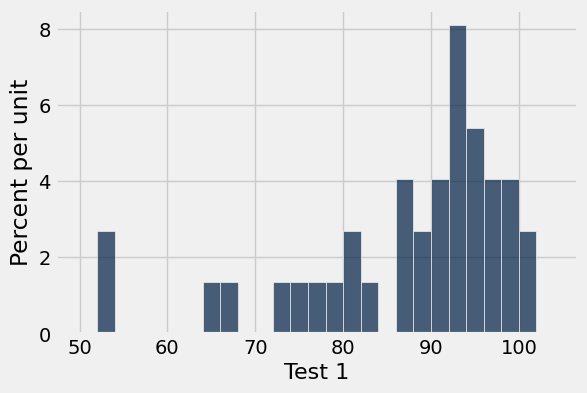

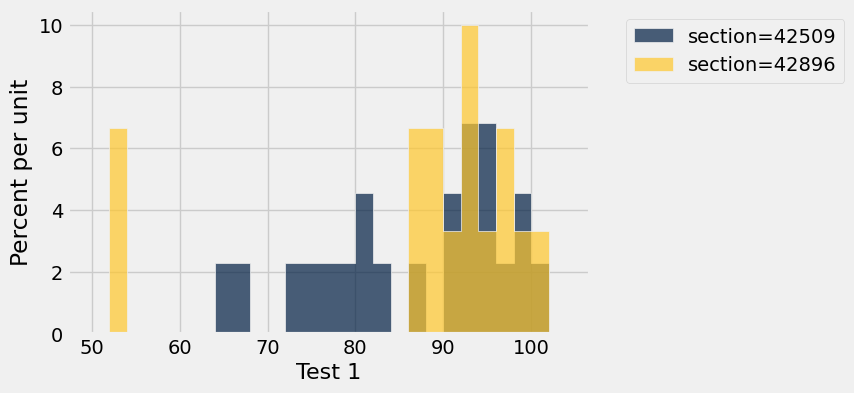

In [4]:
math_raw = Table.read_table('Math101i grades after Test 1.csv')
math101 = (math_raw.take(np.arange(1, math_raw.num_rows-1))
    .where('Test 1', are.not_equal_to(''))
    .where('Test 1', are.not_equal_to('nan'))
    .where('Test 1', are.not_equal_to('0')))
math = Table().with_columns('Test 1', math101.apply(float, 'Test 1'),
                            'section', math101.column('Section'))

math.hist('Test 1', bins=np.arange(50,105, 2))
math.hist(group='section', bins=np.arange(50,105, 2))
math.group('section', np.average)

#np.average(math['Test 1'])

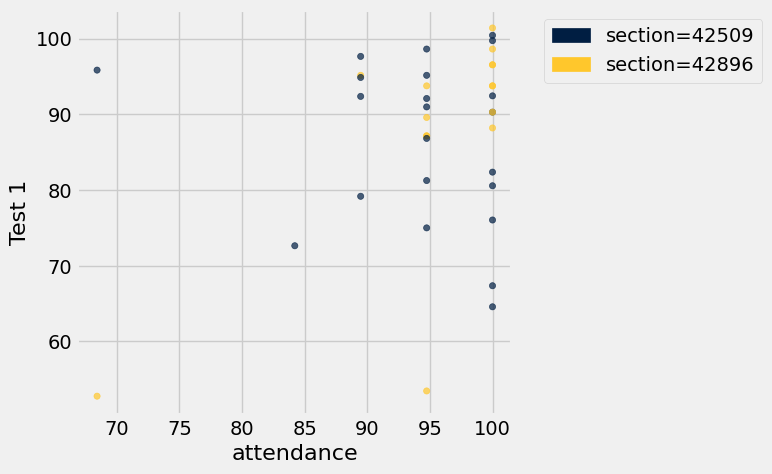

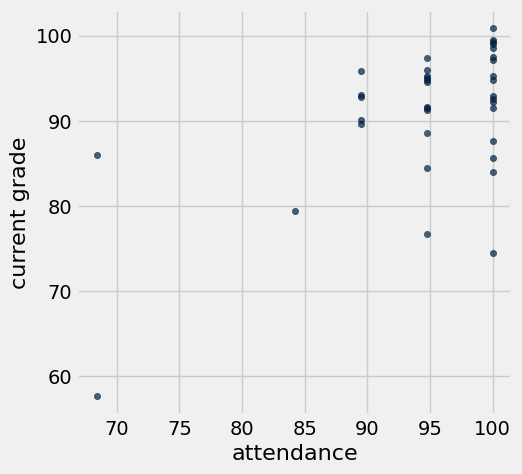

In [5]:
math_stats = Table().with_columns('Test 1', math101.apply(float, 'Test 1'),
                            'section', math101.column('Section'),
                           'attendance', math101.apply(float, 'Attendance'),
                            'quiz', math101.apply(float, 'Quizzes'),
                            'current grade', math101.apply(float, 'Current Score'))
math_stats.scatter('attendance', 'Test 1', group = 'section')
math_stats.scatter('attendance', 'current grade')

#### Begin real example

In [7]:
scores = Table.read_table('scores_by_section.csv')
scores

Section,Midterm
1,22
2,12
2,23
2,14
1,20
3,25
4,19
1,24
5,8
6,14


In [8]:
scores.group('Section')

Section,count
1,32
2,32
3,27
4,30
5,33
6,32
7,24
8,29
9,30
10,34


In [16]:
scores.group('Section', np.average).show()

Section,Midterm average
1,15.5938
2,15.125
3,13.6667
4,14.7667
5,17.4545
6,15.0312
7,16.625
8,16.3103
9,14.5667
10,15.2353


Lock in the observed statistic, then draw one sample under the null:

In [17]:
observed_average = 13.6667 

In [18]:
random_sample = scores.sample(27, with_replacement=False)
random_sample

Section,Midterm
11,10
4,18
9,25
4,7
10,0
5,17
2,0
7,20
1,18
12,13


In [19]:
np.average(random_sample.column('Midterm'))

14.666666666666666

Package the draw into a function and simulate 50,000 of them:

In [20]:
# Simulate one value of the test statistic 
# under the hypothesis that the section is like a random sample from the class
def random_sample_midterm_avg():
    random_sample = scores.sample(27, with_replacement = False)
    return np.average(random_sample.column('Midterm'))

In [21]:
# Simulate 50,000 copies of the test statistic

sample_averages = make_array()

for i in np.arange(50000):
    sample_averages = np.append(sample_averages, random_sample_midterm_avg())    

### Our Decision

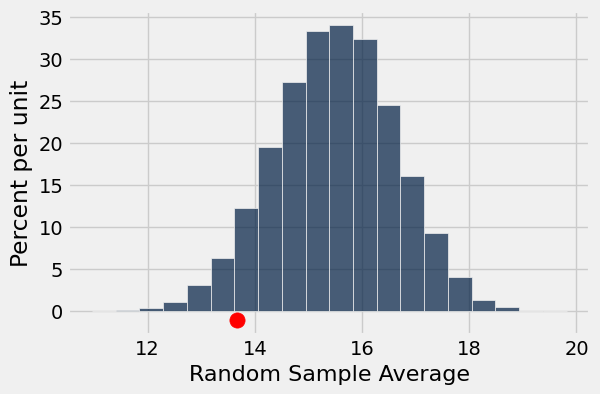

In [22]:
# Compare the simulated distribution of the statistic
# and the actual observed statistic
averages_tbl = Table().with_column('Random Sample Average', sample_averages)
averages_tbl.hist(bins = 20)
plots.scatter(observed_average, -0.01, color='red', s=120);

### Approach 1: p-value

In [23]:
# (1) Calculate the p-value: simulation area beyond observed value
np.count_nonzero(sample_averages <= observed_average) / len(sample_averages)
# (2) See if this is less than 5%

0.05664

In [24]:
# Another way 
np.mean(sample_averages <= observed_average)

0.056640000000000003

### Approach 2: significance threshold

In [28]:
# (2) Find simulated value corresponding to 
#     significance, alpha = 5% of 50,000 simulations = 2500 
#                                              --> the 2500th item in a sorted array of simulated test averages
significance_threshold_index = int(len(sample_averages)*0.05)
print('Significance threshold of alpha = 0.05:', significance_threshold_index)

five_percent_threshold = averages_tbl.sort(0).column(0).item(significance_threshold_index)
five_percent_threshold

Significance threshold of alpha = 0.05: 2500


13.62962962962963

In [29]:
# (2) See if this value is greater than observed value
observed_average < five_percent_threshold

False

### Visual Representation

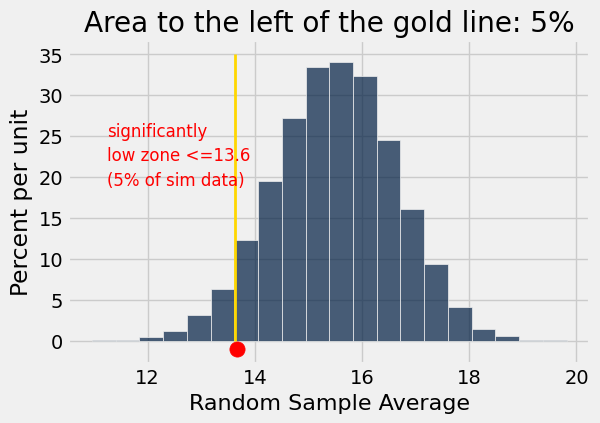

In [51]:
averages_tbl.hist(bins = 20)
plots.plot([five_percent_point, five_percent_point], [0, 0.35], color='gold', lw=2)
plots.title('Area to the left of the gold line: 5%')
plots.text(11.25, .25, "significantly", fontsize=12, color="red")
plots.text(11.25, .22, f'''low zone <={np.round(five_percent_point,1)}''', fontsize=12, color="red")
plots.text(11.25, .19, "(5% of sim data)", fontsize=12, color="red")
plots.scatter(observed_average, -0.01, color='red', s=120);

---
### Try It 1: 2000 coins 🪙 (Type I error...wrong conclusions)

2000 people each toss a fair coin 1000 times and run a hypothesis test:

- **Null:** the coin is fair. **Alternative:** it isn't.
- **Test statistic:** |number of heads − 50|. **Cutoff:** p < 0.05.

All 2000 coins really are fair. **About how many people will wrongly conclude their coin is unfair?** Fill in the cells to find out.

In [ ]:
# Fill in
num_people = ....
num_tosses = ...
fair_coin = ...

In [ ]:
# Fill in
def get_one_statistic():
    num_heads_in_1000_tosses = ...
    return 

In [ ]:
# Fill in
# Generate statistics for the 2000 people in the room
peoples_statistics = ...

for ...:
    peoples_statistics = ...

In [ ]:
# Fill in
# Now perform the hypothesis test (simulate 10000 test statistics under the null hypothesis)
# NOTE, we will just do this once. All 2000 people should end up with similar empirical 
# distributions of the test statistic
simulated_statistics = ...

for i in np.arange(10000):
    simulated_statistics = ...

In [ ]:
# Fill in
# Plot the empirical distribution of test statistic
stats_table = ...


In [ ]:
# Fill in
# Get each person's P-value 
p_vals = ...
for persons_stat in peoples_statistics:
    p_vals= ...
    
p_vals

Cut off: |Heads - 500| statistic >= 31.0
Number of people in significant zone: 85
Percent of people in significant zone: 0.0425


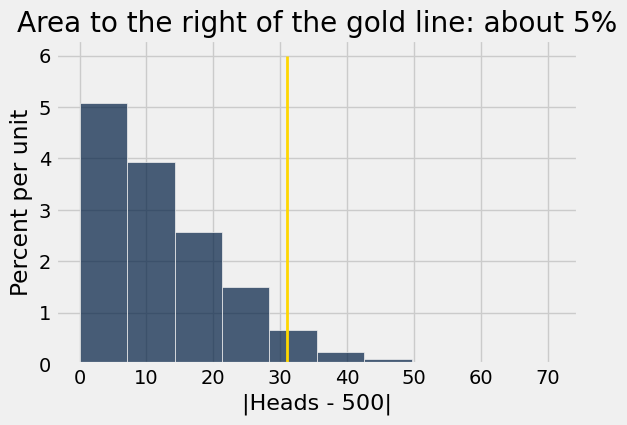

In [67]:
# How many of the 2000 get a p-value below 0.05?



<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Everything is the simulation recipe, the punchline is the last line.*

```python
# How many of the 2000 get a p-value below 0.05?

num_people = 2000
num_tosses = 1000   # I upped it from 100 -> 1000
                    #     histogram = discrete so we need a larger range of values
                    #     to capture the 5% (rather than rounding)
fair_coin = make_array('heads', 'tails')

def get_one_statistic():
    num_heads_in_1000_tosses = sum(np.random.choice(fair_coin, num_tosses) == 'heads')
    return abs(num_heads_in_1000_tosses - 500)

# Statistics for the 2000 people in the room
peoples_statistics = make_array()
for i in np.arange(num_people):
    peoples_statistics = np.append(peoples_statistics, get_one_statistic())

# Null distribution — simulated once, shared by everyone
simulated_statistics = make_array()
for i in np.arange(10000):
    simulated_statistics = np.append(simulated_statistics, get_one_statistic())


stats_table = Table().with_column('|Heads - 500|', simulated_statistics)

# calculate significance value, alpha = 0.05
#    take the right most 5% simuilated vals
five_percent_point = stats_table.sort(0, descending=True).column(0).item(int(len(simulated_statistics)*0.05)-1)
print('Cut off: |Heads - 500| statistic >=',five_percent_point)

# plot!
stats_table.hist()
plots.plot([five_percent_point, five_percent_point], [0, 0.06], color='gold', lw=2)
plots.title('Area to the right of the gold line: about 5%');

# Each person's p-value
p_vals = make_array()
for persons_stat in peoples_statistics:
    p_vals = np.append(p_vals, np.mean(simulated_statistics >= persons_stat))


# Find out how many people got signficantly less than half/half (alpha = 0.05)
print('Number of people in significant zone:',sum(p_vals <= 0.05))
print('Percent of people with p-val <= 0.05:',sum(p_vals <= 0.05)/len(p_vals))
```

</details>

> **The summary**: with a 5% cutoff, about 5% of *true* nulls get rejected: here, ~100 innocent coins were thought to be Unfair!!! A p-value cutoff is an **error rate you're agreeing to**, not a truth detector. Remember this every time you read "statistically significant."


---
## 2. Comparing Two Samples (A/B Testing)

New question type: do babies of smoking mothers weigh less? Two groups: smokers and non-smokers. Are the two distributions *really* different, or is the gap just sampling noise?

In [52]:
births = Table.read_table('baby.csv')

In [53]:
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


For today, just the smoking label and the birth weight:

In [54]:
smoking_and_birthweight = births.select('Maternal Smoker', 'Birth Weight')

In [55]:
smoking_and_birthweight.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


Overlaid histograms, the picture version of the question:

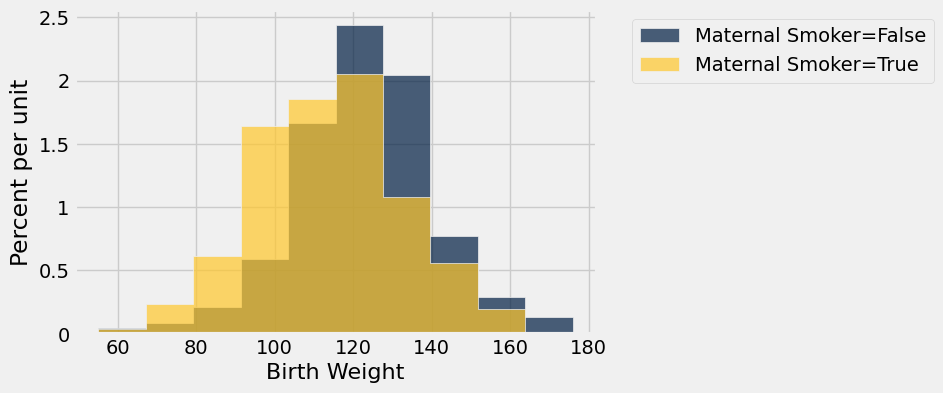

In [19]:
smoking_and_birthweight.hist('Birth Weight', group='Maternal Smoker')

### Test Statistic

[Question] What values of our statistic are in favor of the alternative: positive or negative?

In [56]:
means_table = smoking_and_birthweight.group('Maternal Smoker', np.average)
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


In [57]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

Package the computation into a function (Lab 7 will thank you):

In [58]:
def difference_of_means(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups"""
    
    #table with the two relevant columns
    reduced = table.select(label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)

In [23]:
difference_of_means(births, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

### Try It 2: A different gap 😊

Smokers' babies weigh less. Do smoking and non-smoking mothers differ in **age** too?

1. Draw the overlaid histograms of `Maternal Age` for the two groups.

2. Use `difference_of_means` to compute the observed age gap (smokers minus non-smokers).

3. Eyeball verdict: does the age gap look as convincing as the weight gap?

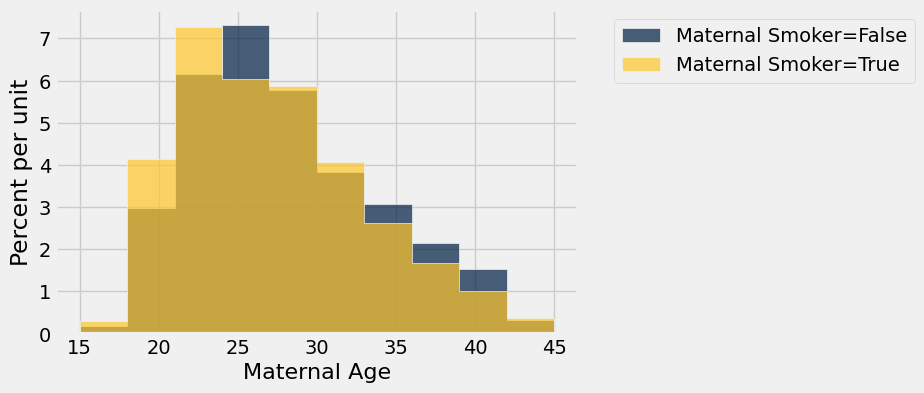

In [26]:
# 1. overlaid age histograms


In [ ]:
# 2. observed age difference


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*The function takes any numerical column; that is why we wrote it.*

```python
# 1.
births.hist('Maternal Age', group='Maternal Smoker')

# 2.
difference_of_means(births, 'Maternal Age', 'Maternal Smoker')
```

*3. Smokers average about 0.8 years younger, and the histograms overlap heavily. Far less dramatic than the 9.27-ounce weight gap. Small does not automatically mean chance, though: the Lecture 20 permutation test will judge it.*

</details>

---
## 3. Random Permutation (Shuffling)

**The null says the label doesn't matter**, so let's literally shuffle the labels and see what differences pure chance produces. `sample(with_replacement=False)` is a shuffle.

In [79]:
paper_people = make_array('Michael', 'Dwight', 'Angela', 'Phyllis', 'Stanley', 'Oscar', 'Jim','Pam','Toby')
job = make_array('best boss', 'assistant regional manager', 'accounting', 'accounting','accounting','accounting','sales','front desk','hr')

office = Table().with_columns("people person's paper people", paper_people, "job", job)

In [80]:
office.sample()

people person's paper people,job
Oscar,accounting
Jim,sales
Angela,accounting
Toby,hr
Angela,accounting
Phyllis,accounting
Dwight,assistant regional manager
Phyllis,accounting
Oscar,accounting


Sampling *without* replacement uses every row exactly once. That is a shuffle:

In [81]:
office.sample(with_replacement = False)

people person's paper people,job
Pam,front desk
Stanley,accounting
Jim,sales
Dwight,assistant regional manager
Toby,hr
Michael,best boss
Oscar,accounting
Angela,accounting
Phyllis,accounting


In [82]:
# job trade!!
office.with_column('Shuffled', office.sample(with_replacement = False).column(0))

people person's paper people,job,Shuffled
Michael,best boss,Pam
Dwight,assistant regional manager,Toby
Angela,accounting,Angela
Phyllis,accounting,Jim
Stanley,accounting,Phyllis
Oscar,accounting,Dwight
Jim,sales,Stanley
Pam,front desk,Michael
Toby,hr,Oscar


---
## 4. Simulation Under the Null

Attach shuffled labels, recompute the difference of means: that's one draw from the null world.

In [83]:
smoking_and_birthweight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [84]:
shuffled_labels = smoking_and_birthweight.sample(with_replacement=False).column('Maternal Smoker')

Attach the shuffled labels next to the real ones:

In [89]:
original_and_shuffled = smoking_and_birthweight.with_column(
    'Shuffled Label', shuffled_labels
)

In [90]:
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Label
False,120,True
False,113,True
True,128,False
True,108,False
False,136,True
False,138,True
False,132,True
False,120,False
True,143,True
False,140,True


Difference of means with the shuffled labels, then with the real ones:

In [91]:
# test statistic under shuffled labels
#    under null hypothesis conditions

difference_of_means(original_and_shuffled, 'Birth Weight', 'Shuffled Label')

-1.761070737541317

In [92]:
# observed test statistic

difference_of_means(original_and_shuffled, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

### Try It 3: Shuffle by hand 😊

1. In one cell, produce a fresh null-world difference yourself: shuffle the labels, attach them, and compute the difference of means. Run it three times and watch the values.

2. Re-running the cell above (real labels) never changes its answer. Why not?

In [ ]:
# 1. your own shuffled difference


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Only the shuffled column is random; the real labels never move.*

```python
# 1.
new_shuffle = smoking_and_birthweight.sample(with_replacement=False).column('Maternal Smoker')
shuffled_tbl = smoking_and_birthweight.with_column('Shuffled Label', new_shuffle)
difference_of_means(shuffled_tbl, 'Birth Weight', 'Shuffled Label')
```

*2. The real labels are fixed data: the same 1,174 rows every run, so the same two group means. Typical shuffled differences stay within about plus or minus 3 ounces, nowhere near the real 9.27.*

</details>

---
## 5. The Permutation Test

Repeat the shuffle 2500 times and compare the observed difference to the shuffled ones:

In [93]:
def one_simulated_difference(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups after shuffling labels"""
    
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(label).with_column('Shuffled Label', shuffled_labels)
    
    return difference_of_means(shuffled_table, label, 'Shuffled Label')   

In [94]:
one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')

-1.2674101497630943

Repeat the shuffle 2500 times to map the null world:

In [95]:
differences = make_array()

for i in np.arange(2500):
    new_difference = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
    differences = np.append(differences, new_difference)

Observed Difference: -9.266142572024918


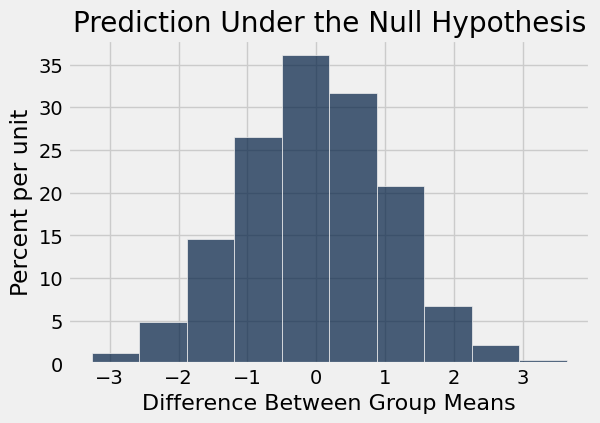

In [96]:
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)
plots.title('Prediction Under the Null Hypothesis');

### Try It 4: The p-value 😊

1. Compute the p-value: the fraction of the 2500 shuffled differences that are *as extreme or more* than `observed_difference`. (Which direction counts as extreme here?)

2. Your conclusion about smoking and birth weight, in hypothesis-test language.

In [ ]:
# 1. p-value


*2. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Small (very negative) differences favor the alternative, so count the low tail.*

```python
# 1.
np.count_nonzero(differences <= observed_difference) / len(differences)
```

*2. p = 0.0: not one of 2500 shuffles came near the observed gap. Reject the null; the two groups' birth weights genuinely differ. (Whether smoking *causes* the gap is a separate question, coming next lecture.)*

</details>

> **Read the picture:** the observed difference (−9.27 oz) is nowhere near the shuffled differences (all within ±5). The null ("smoking label doesn't matter") is untenable. Lab 7 (Great British Bake Off) is this exact test with cake. 🍰

---
> **Today's takeaway:** a p-value cutoff is an error rate; and to compare two groups, shuffle the labels, if the observed gap dwarfs the shuffled gaps, the groups genuinely differ.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — permutation test
```python
shuffled = t.sample(with_replacement=False).column(group_label)
one_diff = difference_of_means(t.with_column('Shuffled', shuffled), value_label, 'Shuffled')
```